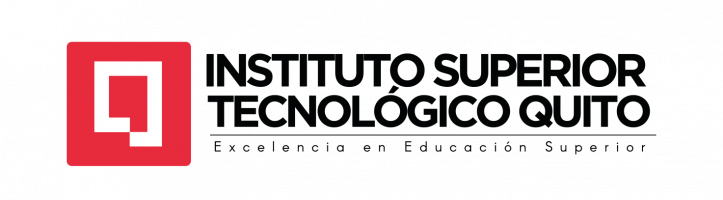

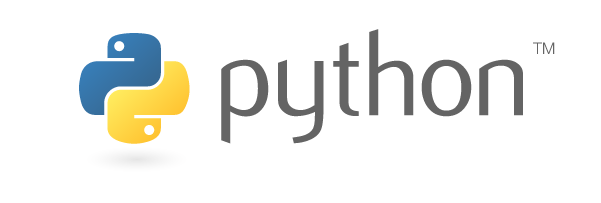

*Byron Armando Melo Aguilar*

*[Enlace a Github](https://github.com/ByronMN911/practicas-machine-learning-I/tree/main/Parcial%20III/Tarea%201)*

Image dimensions:  (256, 256, 3)


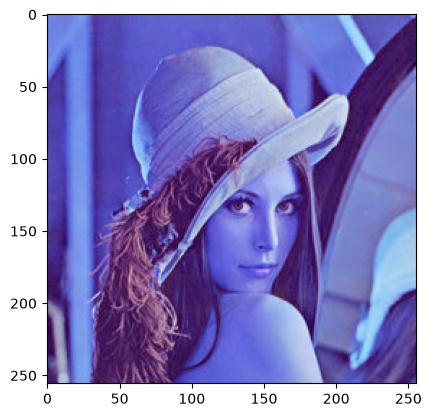

In [6]:
# READ AN IMAGE
# pip install opencv-python o conda install opencv-python
import matplotlib.pyplot as plt
import cv2
import numpy as np

img = cv2.imread('images/Lena_RGB.png')
print('Image dimensions: ', np.shape(img))
plt.imshow(img, cmap='gray')
plt.show()

In [7]:
# Extraer por separado la imagen de grises de cada canal
R = img[:,:,2]
G = img[:,:,1]
B = img[:,:,0]

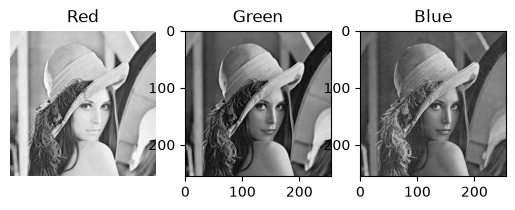

In [8]:
# Visualizar los canales en un subplot
fig, ax = plt.subplots(1,3)
ax[0].imshow(R, cmap='gray'), ax[0].set_title('Red'), ax[0].axis('off')
ax[1].imshow(G, cmap='gray'), ax[1].set_title('Green')
ax[2].imshow(B, cmap='gray'), ax[2].set_title('Blue')
plt.show()

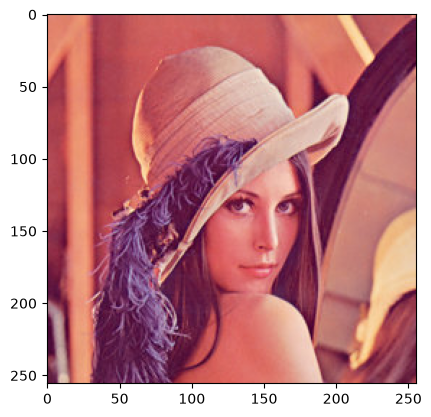

In [9]:
# Convertir BGR en RGB
RGB_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(RGB_img, cmap='gray')
plt.show()

### TRANSFORMACIONES DE INTENSIDAD

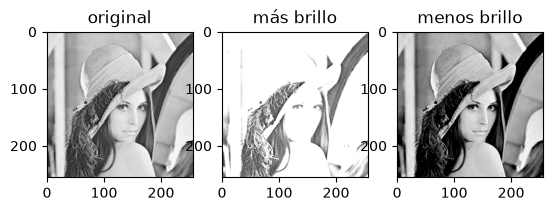

In [10]:
# CAMBIO DE BRILLO
img = cv2.imread('images/Lena_RGB.png')
img = img[:,:,2]  # Extraemos solo el canal rojo (en BGR, el índice 2 es R)
                   # Esto convierte la imagen en una sola "capa" (escala de grises usando solo el canal rojo)

mas_brillo = 100   # Valor a sumar a cada pixel (aumenta el brillo)
menos_brillo = -100  # Valor a restar (disminuye el brillo)

# cv2.add() hace "saturación": si el resultado pasa de 255 lo deja en 255,
# y si es menor que 0 lo deja en 0. Esto evita el "desborde" (overflow) que
# ocurriría con una suma normal de numpy (ej. 200 + 100 = 300, pero en uint8
# eso se desbordaría y daría un valor incorrecto como 44)
mas_brillo_img = cv2.add(img, mas_brillo)   # Importante el "cv2.add" en vez de "+"
menos_brillo_img = cv2.add(img, menos_brillo)

# Mostramos las 3 versiones lado a lado para comparar
fig, ax = plt.subplots(1,3)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(mas_brillo_img, cmap='gray'), ax[1].set_title('más brillo')
ax[2].imshow(menos_brillo_img, cmap='gray'), ax[2].set_title('menos brillo')
plt.show()

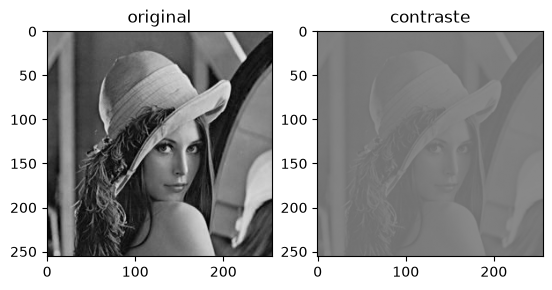

In [11]:
# CAMBIO DE CONTRASTE de acuerdo con el programa GIMP
img = cv2.imread('images/Lena_RGB.png')
img = img[:,:,1]  # Extraemos solo el canal verde

contraste = -100  # Valor de contraste deseado, en el rango típico [-127, 127]
                   # (negativo = menos contraste, positivo = más contraste)

# Fórmula que replica el control de contraste de GIMP:
# convierte el valor "contraste" (-127 a 127) en un factor de escala (f)
f = 131*(contraste + 127)/(127*(131-contraste))

alpha_c = f          # Factor multiplicativo (ganancia): estira o comprime los valores de intensidad
gamma_c = 127*(1-f)  # Factor aditivo (offset): recentra los valores para que el punto medio (127) no se mueva

# cv2.addWeighted calcula: dst = alpha_c*img + 0*img + gamma_c
# Aquí usamos el mismo "img" dos veces pero con peso 0 en el segundo término,
# así que en la práctica es: nueva_img = alpha_c * img + gamma_c
contrast_img = cv2.addWeighted(img, alpha_c, img, 0, gamma_c)

# vmin=0, vmax=255 fuerza a matplotlib a usar siempre la misma escala de grises,
# para que la comparación visual entre ambas imágenes sea justa
fig, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray', vmin=0, vmax=255), ax[0].set_title('original')
ax[1].imshow(contrast_img, cmap='gray', vmin=0, vmax=255), ax[1].set_title('contraste')
plt.show()

### CONVERSIONES DEL ESPACIO DE COLOR

In [12]:
# RGB to CMYK
import numpy as np
from skimage import io

img = io.imread('images/colores.png')
rgb = img.copy()

# Normalizamos los valores RGB al rango [0, 1] (originalmente están en [0, 255])
rgb_p = rgb.astype('uint8') / 255

# Calculamos el canal K (negro/black key)
# K representa qué tan "oscuro" es el pixel: si el máximo de R,G,B es alto (color claro),
# K es bajo; si el máximo es bajo (color oscuro), K es alto.
# axis=2 porque la imagen tiene forma (alto, ancho, canales) y queremos el máximo
# entre los canales R, G, B para cada pixel.
with np.errstate(invalid='ignore', divide='ignore'):
    K = 1 - np.max(rgb_p, axis=2)

# Extraemos los canales R, G, B por separado para aplicar la fórmula
R = rgb_p[:, :, 0]
G = rgb_p[:, :, 1]
B = rgb_p[:, :, 2]

# Ecuaciones de conversión RGB -> CMYK (según el modelo estándar):
# C = (1 - R - K) / (1 - K)
# M = (1 - G - K) / (1 - K)
# Y = (1 - B - K) / (1 - K)
#
# Estas fórmulas "extraen" la componente de negro (K) de cada canal de color,
# dejando solo la información de color puro (cian, magenta, amarillo).
# Usamos np.errstate arriba porque cuando K=1 (pixel totalmente negro),
# el denominador (1-K) es 0 y se produce una división por cero (0/0 = NaN),
# lo cual

In [13]:
# Otras conversiones
from skimage import io
img = cv2.imread('images/Lena_RGB.png')  # OpenCV lee las imágenes en formato BGR (no RGB)

# Convertimos la imagen a distintos espacios de color, cada uno útil para diferentes tareas:

gray_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)   # Escala de grises (1 solo canal de intensidad)

HSV = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)         # (H)ue = tono/color, (S)aturation = saturación,
                                                     # (V)alue = brillo/valor. Útil para segmentar por color
                                                     # ya que separa el "color" de la "iluminación"

Lab = cv2.cvtColor(img, cv2.COLOR_BGR2Lab)         # (L) = Luminosidad, a = eje verde-rojo,
                                                     # b = eje azul-amarillo. Diseñado para ser
                                                     # perceptualmente uniforme (más cercano a cómo el ojo humano percibe diferencias de color)

YCrCb = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)     # Y = Luma (luminancia/brillo), Cr = crominancia roja,
                                                     # Cb = crominancia azul. Muy usado en compresión de
                                                     # video/imagen (ej. JPEG) porque el ojo humano es más
                                                     # sensible al brillo que al color

### TRANSFORMACIONES GEOMÉTRICAS

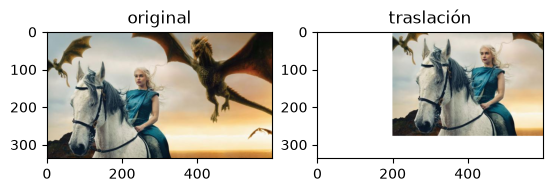

In [14]:
# TRASLACIÓN
img = io.imread('images/GOT.png')
rows, cols, ch = img.shape  # Obtenemos alto, ancho y número de canales de la imagen

# Matriz de transformación afín 2x3 para traslación:
# [[1, 0, tx],   tx = desplazamiento en x (horizontal)
#  [0, 1, ty]]   ty = desplazamiento en y (vertical)
# Aquí: mover 200 px a la derecha (x) y 60 px hacia arriba (y, valor negativo)
M = np.float32([[1,0,200],[0,1,-60]])  # Defino la matriz de transformación

# warpAffine aplica la transformación M a la imagen, generando una nueva
# imagen del mismo tamaño (cols, rows). Las zonas que "quedan vacías" tras
# el desplazamiento se rellenan por defecto con negro (0)
new_img = cv2.warpAffine(img,M,(cols,rows))  # Aplico la transformación

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('traslación')
plt.show()

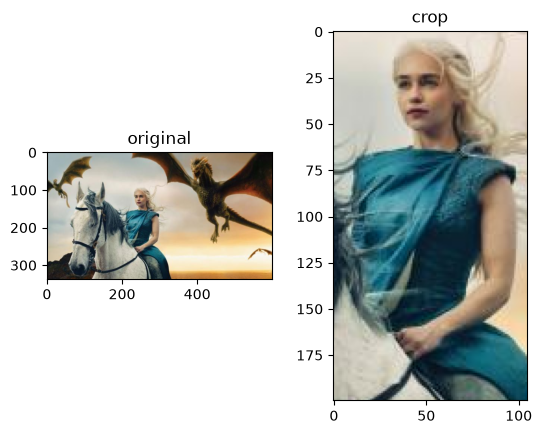

In [15]:
# CROPPING
img = io.imread('images/GOT.png')

# El recorte se hace directamente con "slicing" de numpy, sin usar OpenCV:
# img[fila_inicio:fila_fin, columna_inicio:columna_fin]
# Aquí tomamos las filas 90 a 290 (alto) y las columnas 200 a 305 (ancho)
new_img = img[90:290, 200:305]

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('crop')
plt.show()

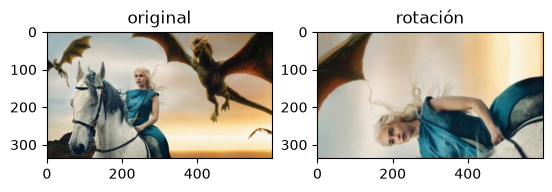

In [16]:
# ROTACIÓN
img = io.imread('images/GOT.png')
rows, cols, ch = img.shape

# getRotationMatrix2D genera la matriz de transformación para rotar la imagen:
# - (cols/2, rows/2): centro de rotación (el centro de la imagen)
# - angle=90: ángulo de rotación en grados (sentido antihorario)
# - scale=2: factor de escala aplicado junto con la rotación (2 = duplica el tamaño)
M = cv2.getRotationMatrix2D((cols/2,rows/2),angle=90,scale=2)  # Defino la matriz de transformación

# Aplicamos la rotación+escala. Como el "canvas" de salida sigue siendo (cols, rows),
# si la imagen escalada es más grande que el canvas original, partes de la imagen
# quedarán "recortadas" fuera de los bordes
new_img = cv2.warpAffine(img,M,(cols,rows))  # Aplico la transformación

figs, ax = plt.subplots(1,2)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(new_img, cmap='gray'), ax[1].set_title('rotación')
plt.show()

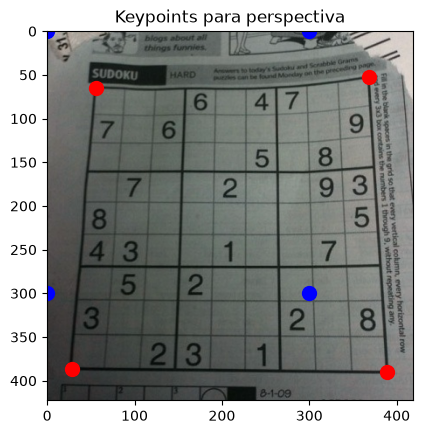

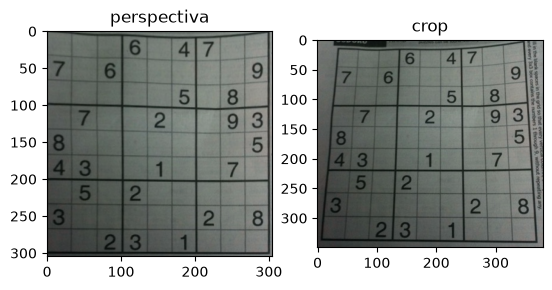

In [17]:
# PERSPECTIVA
img = cv2.imread('images/sudoku.png')
rows, cols, ch = img.shape

# pts1: 4 puntos de referencia en la imagen ORIGINAL (las 4 esquinas del
# tablero de sudoku, que en la foto está inclinado/deformado)
pts1 = np.float32([[56,65],[368,52],[28,387],[389,390]])

# pts2: dónde queremos que esos 4 puntos terminen en la imagen DE SALIDA
# (formando un cuadrado perfecto de 300x300, ya "enderezado")
pts2 = np.float32([[0,0],[300,0],[0,300],[300,300]])

# Visualizamos los puntos de origen (rojo) y destino (azul) sobre la imagen
# para confirmar que están bien ubicados antes de aplicar la transformación
plt.imshow(img, cmap='gray')
for i in range(0,4):
    plt.plot(pts1[i,0], pts1[i,1], 'or', markersize=10)  # puntos originales en rojo
    plt.plot(pts2[i,0], pts2[i,1], 'ob', markersize=10)  # puntos destino en azul
plt.title('Keypoints para perspectiva')
plt.show()

# getPerspectiveTransform calcula la matriz de homografía (3x3) que mapea
# los 4 puntos de pts1 a los 4 puntos de pts2 (a diferencia de warpAffine,
# esta transformación sí puede simular efectos de perspectiva/profundidad)
M = cv2.getPerspectiveTransform(pts1,pts2)  # Defino la matriz de transformación

# Aplicamos la transformación de perspectiva; el resultado es una imagen
# de 305x305 con el tablero "enderezado" como si se viera de frente
pers = cv2.warpPerspective(img,M,(305,305))  # Aplico la transformación

# Recorte simple (crop) de la imagen original, solo para comparar visualmente
crop = img[50:400,20:400]

figs, ax = plt.subplots(1,2)
ax[0].imshow(pers, cmap='gray'), ax[0].set_title('perspectiva')
ax[1].imshow(crop, cmap='gray'), ax[1].set_title('crop')
plt.show()

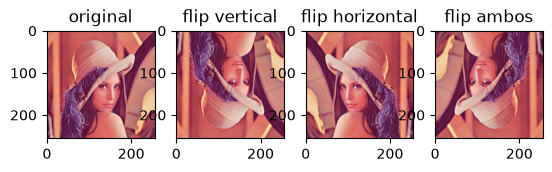

In [18]:
# FLIPPING
# Leer la imagen "Lena_RGB.png" en formato RGB
img = io.imread('images/Lena_RGB.png')

# Voltear la imagen para conseguir las siguientes transformaciones. Utiliza el método "cv2.flip()"
# cv2.flip(img, flipCode):
#   flipCode = 0  -> voltea verticalmente (arriba-abajo, sobre el eje horizontal)
#   flipCode > 0  -> voltea horizontalmente (izquierda-derecha, sobre el eje vertical)
#   flipCode < 0  -> voltea en ambos ejes a la vez (equivale a rotar 180°)
flipVertical = cv2.flip(img,0)
flipHorizontal = cv2.flip(img,1)
flipBoth = cv2.flip(img,-1)

figs, ax = plt.subplots(1,4)
ax[0].imshow(img, cmap='gray'), ax[0].set_title('original')
ax[1].imshow(flipVertical, cmap='gray'), ax[1].set_title('flip vertical')
ax[2].imshow(flipHorizontal, cmap='gray'), ax[2].set_title('flip horizontal')
ax[3].imshow(flipBoth, cmap='gray'), ax[3].set_title('flip ambos')
plt.show()